In [1]:
# ============================================
# EDA + CLEANING NOTEBOOK
# ============================================

import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

In [ ]:
# -----------------------------
# Load dataset
# -----------------------------
df = pd.read_csv(r"C:\Users\shiro\OneDrive\Desktop\Python files\Maternal_health_risk_Project\VIz Project\data\synthetic_maternal_data.csv")
df.head()






In [7]:
numeric_df = df.select_dtypes(include=['float64', 'int64'])

In [3]:
# -----------------------------
# Basic info
# -----------------------------
print(df.info())
print(df.describe())
print(df.isnull().sum())


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3030 entries, 0 to 3029
Data columns (total 7 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   Age          2726 non-null   float64
 1   SystolicBP   2732 non-null   float64
 2   DiastolicBP  2736 non-null   float64
 3   BS           2741 non-null   float64
 4   BodyTemp     2734 non-null   float64
 5   HeartRate    2736 non-null   float64
 6   RiskLevel    3030 non-null   object 
dtypes: float64(6), object(1)
memory usage: 165.8+ KB
None
               Age   SystolicBP  DiastolicBP           BS     BodyTemp  \
count  2726.000000  2732.000000  2736.000000  2741.000000  2734.000000   
mean     29.895818   120.252196    72.304094     7.303287    98.334441   
std       9.665420    21.856220    14.559805     2.354312     0.924476   
min      10.000000    70.000000    40.000000     4.000000    96.000000   
25%      23.000000   105.000000    63.000000     5.860000    97.800000   
50%      30.0

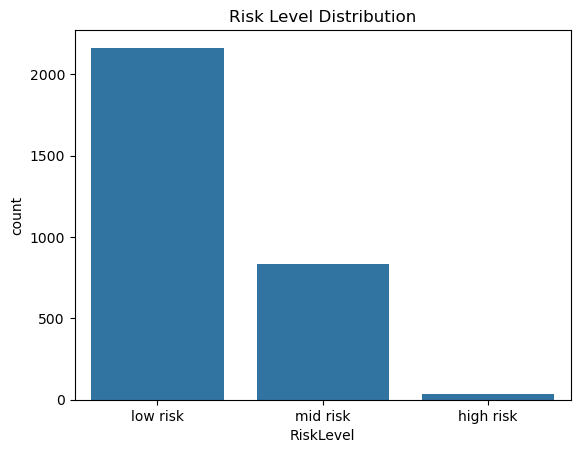

In [4]:
# -----------------------------
# Class distribution
# -----------------------------
sns.countplot(data=df, x="RiskLevel")
plt.title("Risk Level Distribution")
plt.show()


In [ ]:
numeric_df.skew()




,Age,SystolicBP,DiastolicBP,BS,BodyTemp,HeartRate
Age,1.000000,0.005134,0.006945,0.036770,0.006985,-0.000014
SystolicBP,0.005134,1.000000,0.934261,0.291447,0.275532,0.227013
DiastolicBP,0.006945,0.934261,1.000000,0.330020,0.330816,0.244592
BS,0.036770,0.291447,0.330020,1.000000,0.449230,0.327357
BodyTemp,0.006985,0.275532,0.330816,0.449230,1.000000,0.335305
HeartRate,-0.000014,0.227013,0.244592,0.327357,0.335305,1.000000


In [9]:
numeric_df.kurt()

Age           -0.164446
SystolicBP    -0.063729
DiastolicBP    0.355423
BS             6.515159
BodyTemp       4.920990
HeartRate      0.306287
dtype: float64

In [10]:
numeric_df.corr()

,Age,SystolicBP,DiastolicBP,BS,BodyTemp,HeartRate
Age,1.000000,0.005134,0.006945,0.036770,0.006985,-0.000014
SystolicBP,0.005134,1.000000,0.934261,0.291447,0.275532,0.227013
DiastolicBP,0.006945,0.934261,1.000000,0.330020,0.330816,0.244592
BS,0.036770,0.291447,0.330020,1.000000,0.449230,0.327357
BodyTemp,0.006985,0.275532,0.330816,0.449230,1.000000,0.335305
HeartRate,-0.000014,0.227013,0.244592,0.327357,0.335305,1.000000


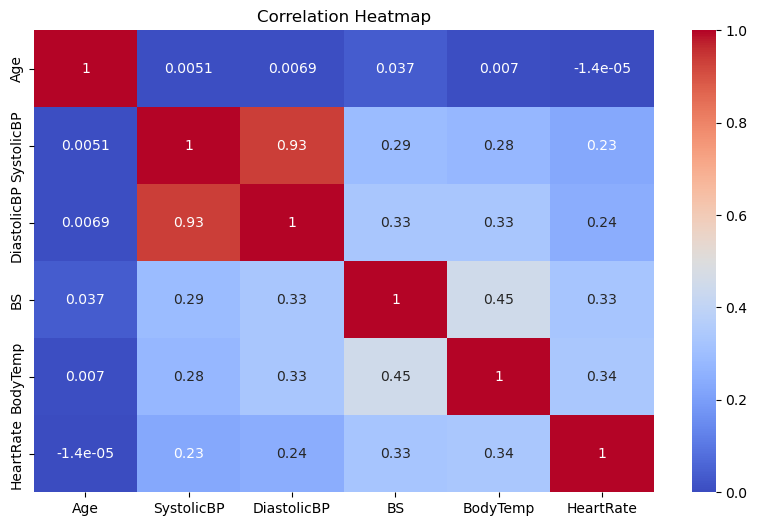

In [11]:
# -----------------------------
# Correlation heatmap
# -----------------------------
plt.figure(figsize=(10,6))
sns.heatmap(numeric_df.corr(), annot=True, cmap="coolwarm")
plt.title("Correlation Heatmap")
plt.show()


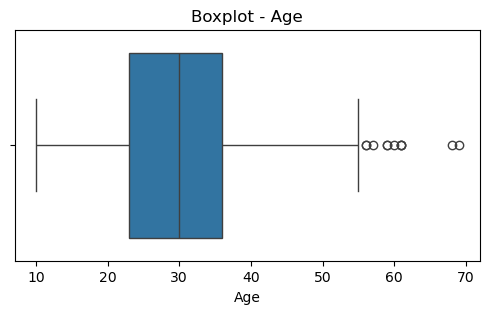

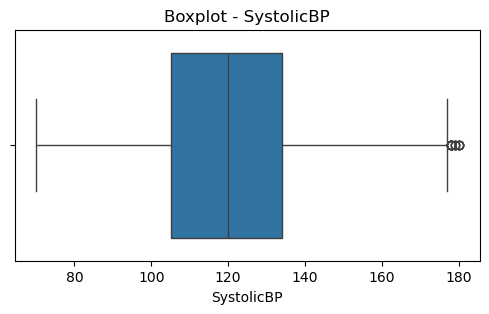

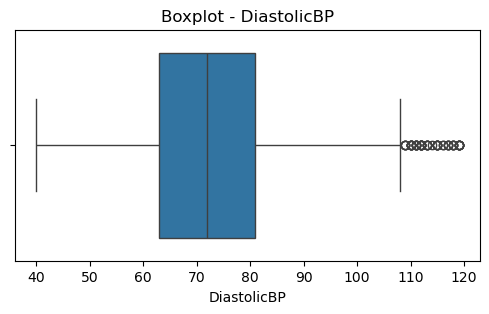

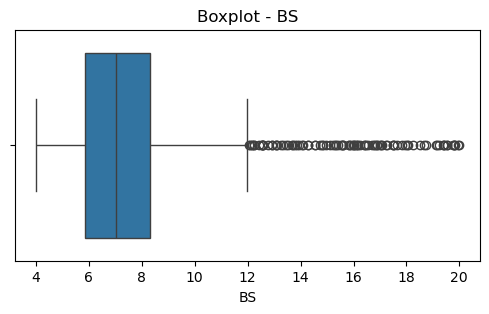

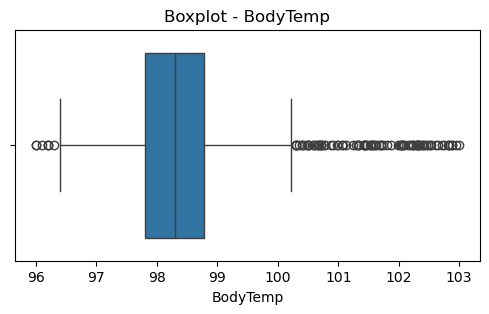

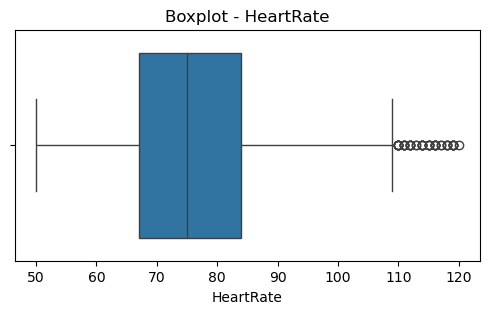

In [12]:
# -----------------------------
# Boxplots for outliers
# -----------------------------
num_cols = df.select_dtypes(include=np.number).columns

for col in num_cols:
    plt.figure(figsize=(6,3))
    sns.boxplot(x=df[col])
    plt.title(f"Boxplot - {col}")
    plt.show()


In [14]:
# -----------------------------
# Cleaning steps
# -----------------------------
df_cleaned = df.copy()

# Remove duplicates
df_cleaned = df_cleaned.drop_duplicates()

# Remove rows with missing values
df_cleaned = df_cleaned.dropna()

# Save cleaned dataset
df_cleaned.to_csv("../data/synthetic_maternal_cleaned.csv", index=False)

df_cleaned.head()


,Age,SystolicBP,DiastolicBP,BS,BodyTemp,HeartRate,RiskLevel
1,46.0,124.0,82.0,9.89,98.0,93.0,mid risk
2,48.0,120.0,73.0,5.00,98.5,62.0,low risk
4,43.0,116.0,60.0,8.37,97.6,80.0,low risk
5,27.0,135.0,92.0,10.41,98.5,55.0,mid risk
9,18.0,124.0,74.0,4.11,98.2,62.0,low risk
